In [22]:
!pip install sionna tensorflow matplotlib torch pandas

In [23]:
# =============================================================================
# CELL 1: ROBUST DATASET GENERATION (SIONNA + CFO)
# =============================================================================
import tensorflow as tf
import numpy as np
import sionna
import os
import torch
import pandas as pd
from dataclasses import dataclass
from sionna.phy.mapping import Constellation, Mapper
from sionna.phy.channel import AWGN

# ---------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------
@dataclass(frozen=True)
class RadioSimConfig:
    """
    Configuration for 16-QAM Signal Generation with CFO.
    """
    # CRITICAL: This determines the output size. 
    # 256 Symbols * 4 bits = 1024 bits = 128 Bytes of text.
    seq_length: int = 256           
    bits_per_symbol: int = 4        # 16-QAM
    
    # SNR Range (dB)
    snr_db_min: float = 12.0         
    snr_db_max: float = 30.0        
    
    # Carrier Frequency Offset (Radians per sample)
    # 0.1 rad/sample is extremely fast spinning (approx Fs/60).
    max_cfo_rad: float = 0.02       
    
    random_phase: bool = True
    seed: int = 144

In [24]:
# ---------------------------------------------------------
# 2. TEXT PROCESSING (Original & Translation)
# ---------------------------------------------------------
def text_to_bits_padded(text, seq_len_symbols, bits_per_symbol):
    """
    Converts a string to a fixed-length bit array.
    """
    # Calculate exact number of bytes needed to fill the symbols
    # e.g., 256 symbols * 4 bits = 1024 bits = 128 bytes
    target_bytes = (seq_len_symbols * bits_per_symbol) // 8
    
    b_data = text.encode('utf-8')
    
    # Truncate if too long
    if len(b_data) > target_bytes:
        b_data = b_data[:target_bytes]
    
    # Pad with nulls if too short
    if len(b_data) < target_bytes:
        b_data += b'\x00' * (target_bytes - len(b_data))
        
    # Bytes -> Bits
    bits = np.unpackbits(np.frombuffer(b_data, dtype=np.uint8))
    return bits.astype(np.int32)

def load_dante_csv(csv_path, cfg):
    print(f"Loading Dante from {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # 1. Extract columns: 'Original' and 'Translation'
    texts_orig = df['Original'].astype(str).tolist()
    texts_trans = df['Translation'].astype(str).tolist()
    
    raw_texts = texts_orig + texts_trans
    print(f"Loaded {len(raw_texts)} raw rows (Original + Translation).")

    # 2. Split by DOT (.) to augment data
    #    This creates more samples from the same text
    processed_sentences = []
    for t in raw_texts:
        parts = t.split('.')
        for p in parts:
            clean_p = p.strip()
            # Filter noise: keep only if > 10 chars
            if len(clean_p) > 10:
                processed_sentences.append(clean_p)
                
    print(f"Augmented to {len(processed_sentences)} text fragments after splitting.")
    
    # 3. Convert to Bits
    all_bits = []
    valid_texts = []
    
    for s in processed_sentences:
        bits = text_to_bits_padded(s, cfg.seq_length, cfg.bits_per_symbol)
        all_bits.append(bits)
        valid_texts.append(s[:100]) # Store snippet for ref
            
    bit_tensor = np.stack(all_bits, axis=0)
    
    # 4. Scramble (Energy Dispersal)
    #    Ensures constellation is fully populated even with padding
    print("Scrambling bits (Simulating Whitening)...")
    np.random.seed(cfg.seed)
    mask = np.random.randint(0, 2, size=bit_tensor.shape, dtype=bit_tensor.dtype)
    scrambled_tensor = np.bitwise_xor(bit_tensor, mask)
    
    return scrambled_tensor, valid_texts, mask

In [25]:
# ---------------------------------------------------------
# 3. PHYSICS SIMULATOR (SIONNA + MANUAL CFO)
# ---------------------------------------------------------
def generate_radio_dataset(cfg: RadioSimConfig, input_bits_np: np.ndarray) -> dict:
    # Setup Sionna components
    rng = tf.random.Generator.from_seed(cfg.seed)
    constellation = Constellation("qam", cfg.bits_per_symbol)
    mapper = Mapper(constellation=constellation)
    awgn = AWGN()

    # Convert to Tensor
    bits = tf.convert_to_tensor(input_bits_np, dtype=tf.int32)
    N = bits.shape[0] # Batch size
    L = bits.shape[1] // cfg.bits_per_symbol # Sequence length in symbols
    
    print(f"Simulating physics: CFO Max={cfg.max_cfo_rad} rad/sample, SNR=[{cfg.snr_db_min}, {cfg.snr_db_max}] dB")
    
    # 1. Map to QAM Symbols
    #    x_clean is the perfect Grid (Visual check: Plot this to see the square)
    x_clean = mapper(bits) # [N, L] complex

    # 2. Apply CFO (Time-Varying Phase Rotation)
    #    Phase(t) = phi_0 + (omega * t)
    
    # A. Initial Phase (phi_0)
    if cfg.random_phase:
        phi_0 = rng.uniform([N, 1], minval=-np.pi, maxval=np.pi, dtype=tf.float32)
    else:
        phi_0 = tf.zeros([N, 1])
        
    # B. Frequency Offset (omega)
    #    Using the config value 0.1 explicitly
    cfo_rad = rng.uniform([N, 1], minval=-cfg.max_cfo_rad, maxval=cfg.max_cfo_rad, dtype=tf.float32)
    
    # C. Time Vector [0, 1, 2, ..., L-1]
    t_vec = tf.range(L, dtype=tf.float32)[tf.newaxis, :] # [1, L]
    
    # D. Total Phase Evolution
    #    Broadcast: [N, 1] + [N, 1]*[1, L] -> [N, L]
    phase_evolution = phi_0 + (cfo_rad * t_vec) 
    
    # E. Apply Rotation
    rot_vector = tf.complex(tf.math.cos(phase_evolution), tf.math.sin(phase_evolution))
    x_rotated = x_clean * rot_vector 

    # 3. Add AWGN Noise
    snr_db = rng.uniform([N, 1], minval=cfg.snr_db_min, maxval=cfg.snr_db_max, dtype=tf.float32)
    no = 1.0 / (10.0 ** (snr_db / 10.0))
    y_noisy = awgn(x_rotated, no)

    # 4. Helpers to save as numpy
    def complex_to_2ch(x):
        return tf.stack([tf.math.real(x), tf.math.imag(x)], axis=1)

    return {
        "iq_noisy": complex_to_2ch(y_noisy).numpy().astype(np.float32), # [N, 2, L]
        "iq_clean": complex_to_2ch(x_clean).numpy().astype(np.float32), # [N, 2, L]
        "cfo_labels": cfo_rad.numpy().astype(np.float32),               # [N, 1]
        "phase_labels": phi_0.numpy().astype(np.float32),               # [N, 1]
        "snr_db": snr_db.numpy().astype(np.float32).flatten()
    }

In [ ]:
# ---------------------------------------------------------
# 4. EXECUTION
# ---------------------------------------------------------
# Config
config = RadioSimConfig(seq_length=256) # Adjust length here

# Load
csv_path = "./data/divina_commedia.csv" # Ensure this path is correct
if not os.path.exists(csv_path):
    print(f"ERROR: File not found at {csv_path}")
else:
    scrambled_bits, texts_list, scramble_mask = load_dante_csv(csv_path, config)

    # Simulate
    data_dict = generate_radio_dataset(config, scrambled_bits)

    # Save to PyTorch format
    torch_data = {k: torch.from_numpy(v) for k, v in data_dict.items()}
    torch_data['texts'] = texts_list
    torch_data['bits'] = torch.from_numpy(scrambled_bits)
    # Save the config seq_len so the loader knows!
    torch_data['seq_len'] = config.seq_length 
    torch_data['scramble_mask'] = torch.from_numpy(scramble_mask)

    output_path = "./data/radio_divina_commedia.pth"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    torch.save(torch_data, output_path)

    print(f"\n[Success] Dataset saved to: {output_path}")
    print(f"Samples: {len(texts_list)}, Seq Len: {config.seq_length}, SNR: {config.snr_db_min}-{config.snr_db_max} dB")

Loading Dante from ./data/divina_commedia.csv...
Loaded 4758 raw rows (Original + Translation).
Augmented to 5140 text fragments after splitting.
Scrambling bits (Simulating Whitening)...
Simulating physics: CFO Max=0.02 rad/sample, SNR=[12.0, 30.0] dB

[Success] Dataset saved to: ./data/radio_divina_commedia.pth
Samples: 5140, Seq Len: 256, SNR: 12.0-30.0 dB


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Visualizing Dante samples...


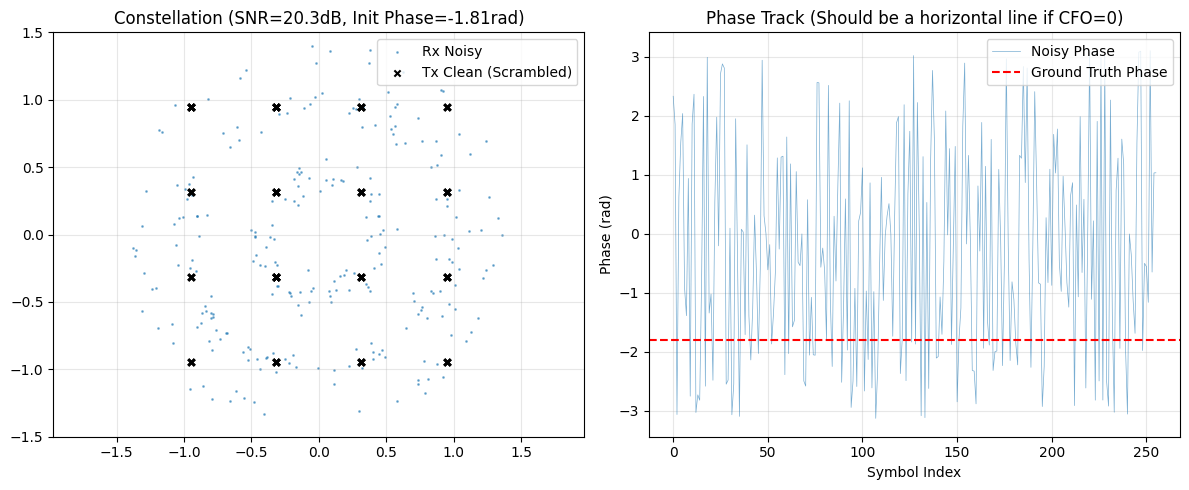

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


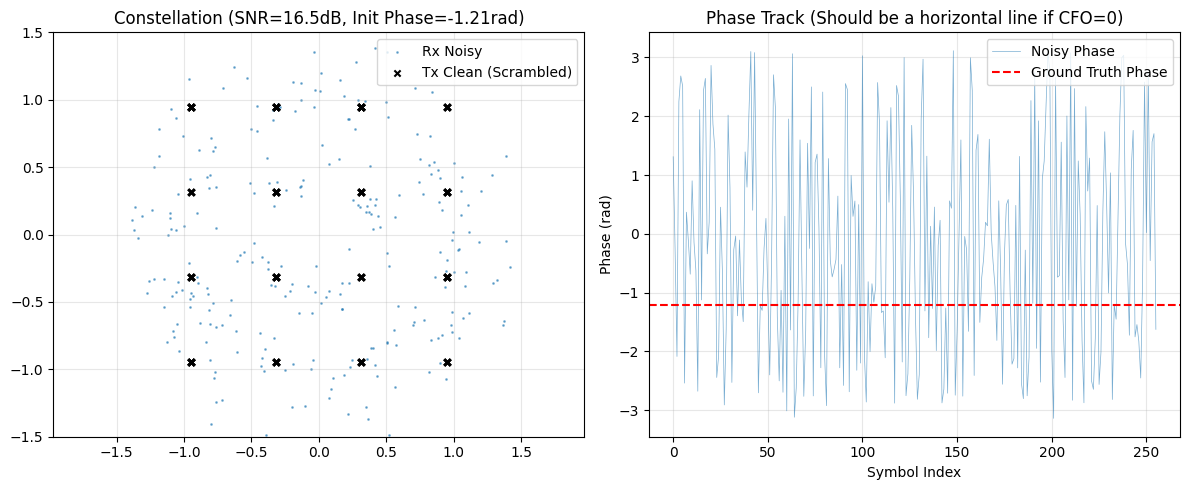

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


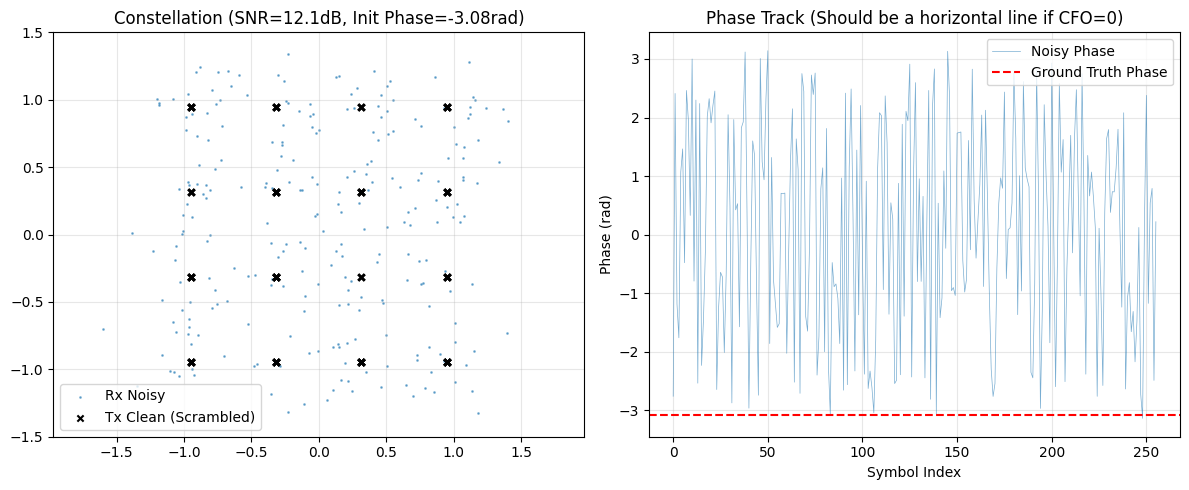

In [27]:
import matplotlib.pyplot as plt

def plot_example(idx, data):
    # Retrieve data using the updated keys from our Dante generator
    iq_n = data['iq_noisy'][idx]
    iq_c = data['iq_clean'][idx]
    
    # Use .get() or handle the updated naming convention
    # In the static version, we use phase_labels; in the CFO version, we used cfo_labels
    phase = data['phase_labels'][idx].item() if 'phase_labels' in data else 0.0
    snr = data['snr_db'][idx].item()
    
    # Convert [2, L] -> Complex [L]
    z_n = iq_n[0] + 1j*iq_n[1]
    z_c = iq_c[0] + 1j*iq_c[1]
    
    plt.figure(figsize=(12, 5))
    
    # 1. Constellation
    plt.subplot(1, 2, 1)
    # If CFO is present and non-zero, it causes the "circular smear"
    plt.title(f"Constellation (SNR={snr:.1f}dB, Init Phase={phase:.2f}rad)")
    plt.scatter(z_n.real.cpu(), z_n.imag.cpu(), s=1, alpha=0.5, label='Rx Noisy')
    plt.scatter(z_c.real.cpu(), z_c.imag.cpu(), s=20, c='k', marker='x', label='Tx Clean (Scrambled)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.xlim(-1.5, 1.5); plt.ylim(-1.5, 1.5)
    
    # 2. Phase Track (Visualizing Static Phase vs CFO)
    plt.subplot(1, 2, 2)
    plt.title("Phase Track (Should be a horizontal line if CFO=0)")
    plt.plot(np.angle(z_n.cpu()), lw=0.5, alpha=0.6, label='Noisy Phase')
    # Plot the ground truth horizontal line
    plt.axhline(y=phase, color='r', linestyle='--', label='Ground Truth Phase')
    plt.xlabel("Symbol Index")
    plt.ylabel("Phase (rad)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize
print("Visualizing Dante samples...")
for i in range(3):
    plot_example(i, torch_data)

In [28]:
# Diagnostic cell: print 5 random generated samples (compact view)
import numpy as np
import torch

SAVE_PATH = "./data/radio_divina_commedia.pth"
SEED = 12345
N_SAMPLES_TO_SHOW = 5
MAX_BITS_PRINT = 64      # how many bits to show (prefix)
MAX_SYMS_PRINT = 32      # how many symbol indices to show
MAX_IQ_PRINT = 16        # how many IQ symbols to print

# 1) load dataset (prefer in-memory torch_data if available)
if "torch_data" in globals() and isinstance(torch_data, dict):
    data = torch_data
    print("Using in-memory 'torch_data' variable.")
else:
    print(f"Loading dataset from '{SAVE_PATH}' ...")
    data = torch.load(SAVE_PATH, map_location="cpu")

# 2) extract fields (support both numpy arrays and torch tensors)
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)

iq_noisy = to_numpy(data["iq_noisy"])    # shape [N, 2, L]
iq_clean = to_numpy(data["iq_clean"])    # shape [N, 2, L]
phase_labels = to_numpy(data["phase_labels"]).reshape(-1)  # shape [N]
snr_db = to_numpy(data["snr_db"]).reshape(-1)             # shape [N]
bits = to_numpy(data["bits"]).astype(np.int32)            # shape [N, L*4]
scramble_mask = to_numpy(data.get("scramble_mask", np.zeros_like(bits))).astype(np.int32)
texts = data.get("texts", None)

N = bits.shape[0]
print(f"Dataset contains {N} samples. Each sample: iq shape {iq_noisy.shape[1:]} , bits length {bits.shape[1]}")

# 3) sampling indices
rng = np.random.default_rng(SEED)
idxs = rng.choice(N, size=min(N_SAMPLES_TO_SHOW, N), replace=False)
print("\nSelected sample indices:", idxs.tolist(), "\n")

# helper to convert bit arrays -> symbol indices (MSB-first packing)
def bits_to_symbol_indices(bit_row, bits_per_symbol=4):
    sym_bits = bit_row.reshape(-1, bits_per_symbol)
    return (sym_bits[:,0]*8 + sym_bits[:,1]*4 + sym_bits[:,2]*2 + sym_bits[:,3]*1)

# pretty print complex arrays with limited length
def complex_list_str(carr, max_print):
    return ", ".join([f"{x.real:+.4f}{x.imag:+.4f}j" for x in carr[:max_print]])

for idx in idxs:
    print("------------------------------------------------------------")
    print(f"SAMPLE {idx}")
    if texts is not None:
        txt = texts[idx]
        # truncate long text
        if txt is None: txt = ""
        if len(txt) > 200: txt_show = txt[:200] + "..."
        else: txt_show = txt
        print(" text (decoded):", repr(txt_show))
    print(" phase_label (rad):", float(phase_labels[idx]))
    print(" snr_db:", float(snr_db[idx]))
    print(" iq_clean shape:", iq_clean[idx].shape, "iq_noisy shape:", iq_noisy[idx].shape)

    # prepare complex vectors
    iqc = iq_clean[idx][0] + 1j * iq_clean[idx][1]
    iqn = iq_noisy[idx][0] + 1j * iq_noisy[idx][1]

    print(f" first {MAX_IQ_PRINT} iq_clean samples: [{complex_list_str(iqc, MAX_IQ_PRINT)}]")
    print(f" first {MAX_IQ_PRINT} iq_noisy  samples: [{complex_list_str(iqn, MAX_IQ_PRINT)}]")

    bitrow = bits[idx]
    print(f" bits length: {bitrow.size}  (showing first {MAX_BITS_PRINT} bits):")
    print(" ", "".join(str(b) for b in bitrow[:MAX_BITS_PRINT]))

    # scramble mask info
    maskrow = scramble_mask[idx] if scramble_mask is not None else None
    if maskrow is not None:
        print(f" scramble mask (first {MAX_BITS_PRINT}):")
        print(" ", "".join(str(int(x)) for x in maskrow[:MAX_BITS_PRINT]))

    # symbol indices computed from bits
    sym_idx = bits_to_symbol_indices(bitrow, bits_per_symbol=4)
    print(f" symbol count: {sym_idx.size}  (showing first {MAX_SYMS_PRINT} indices):")
    print(" ", sym_idx[:MAX_SYMS_PRINT].tolist())

    # show histogram of symbol indices (compact)
    uniq, counts = np.unique(sym_idx, return_counts=True)
    hist = ", ".join([f"{u}:{c}" for u,c in zip(uniq, counts) if c>0][:16])
    print(" symbol histogram (non-zero counts, truncated):", hist)

    # Optional: show the first symbol's bit quartet and its computed index
    if sym_idx.size > 0:
        first_bits = bitrow[:4].tolist()
        print(f" first symbol bits (b0 b1 b2 b3): {first_bits} -> index {int(sym_idx[0])}")

    print("------------------------------------------------------------\n")

Using in-memory 'torch_data' variable.
Dataset contains 5140 samples. Each sample: iq shape (2, 256) , bits length 1024

Selected sample indices: [3591, 1167, 1049, 4052, 1627] 

------------------------------------------------------------
SAMPLE 3591
 text (decoded): '«O anima, che vai per esser beata con quelle membra con le quali nascesti» venivano gridando, «ferma'
 phase_label (rad): 1.7184374332427979
 snr_db: 16.351970672607422
 iq_clean shape: (2, 256) iq_noisy shape: (2, 256)
 first 16 iq_clean samples: [-0.9487-0.9487j, -0.9487-0.3162j, +0.9487+0.3162j, -0.3162-0.3162j, -0.9487-0.9487j, +0.3162+0.3162j, +0.9487+0.9487j, +0.9487-0.3162j, -0.9487+0.9487j, +0.3162+0.3162j, +0.3162-0.9487j, +0.9487-0.9487j, +0.9487-0.3162j, -0.9487-0.3162j, -0.3162-0.3162j, -0.9487-0.9487j]
 first 16 iq_noisy  samples: [+0.9141-0.8705j, +0.6229-0.9371j, -0.3272+0.8108j, +0.5257-0.1212j, +1.1753-0.8322j, -0.4937+0.1667j, -1.0648+0.6856j, +0.0655+0.9104j, -0.5872-1.3284j, -0.5123+0.1602j, +0.7747+0